In [16]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [17]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [ ]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=1.6e15):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/S" in state_hist:
            return state_hist["state/S"][..., 0:1]
        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

        raise KeyError(
            f"Neither state/S nor state/mixed_state found. Available state vars: {sorted(state_hist.keys())}"
        )

In [29]:
nmodel = neml2.load_model("new_model_test.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["Bk_X", "C_X", "E_X", "E_Y", "G_X", "G_Y", "H_0_X",
                                                                            "T_0_X", "T_ref_X", "T_ref_Y", "athermal_alpha", "athermal_b",
                                                                            "elasticity_nu", "flow_rate_b", "g_X", "k1_X", "k2_X",
                                                                            "shear_athermal_m", "shear_eff_m", "sy_X", "sy_Y", "tau_p_X",
                                                                            "tau_p_Y", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_p", "v_disl_q"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: Bk_X [Scalar][Double][cuda:0]
            Bk_Y [Scalar][Double][cuda:0]
            C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_X [Scalar][Double][cuda:0]
            E_Y [Scalar][Double][cuda:0]
       

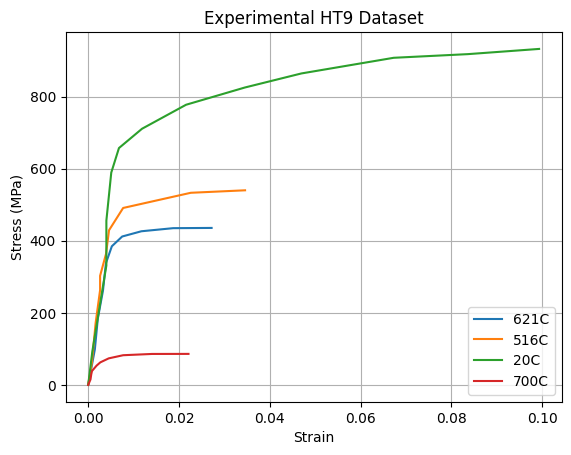

In [30]:
# Load experimental data
path = '/home/colinmoose/neml2/cmg_projects/tensile_data/HT9_var_temp_and_erate'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if 'RT' in filename:
            temp_label = '20'
        elif '516' in filename:
            temp_label = '516'
        elif '621' in filename:
            temp_label = '621'
        elif '700' in filename:
            temp_label = '700'
        else:
            temp_label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{temp_label}_strain', 'y':f'{temp_label}_stress'})
        data_frames[temp_label] = new_df

strain_data = {}
stress_data = {}

for temp_label, df in data_frames.items():
    strain_col = f'{temp_label}_strain'
    stress_col = f'{temp_label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    max_stress_idx = torch.argmax(stress).item()
    strain = strain[:max_stress_idx + 1]
    stress = stress[:max_stress_idx + 1]
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[temp_label] = strain
    stress_data[temp_label] = stress

# Plot initial dataset
plt.figure()
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), label=f"{temp_label}C")
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Experimental HT9 Dataset')
plt.grid()
plt.legend()
plt.show()

In [31]:
nbatch = 4
ntemperature = 4
ntime = 100

rates = torch.tensor([1.0e-4, 4.0e-5, 4.0e-3, 1.38e-6], device=device)
temperatures = torch.tensor([293.15, 789.15, 894.15, 973.15], device=device)

time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))

    min_strain = strain_data[t_label].min().item()
    max_strain = strain_data[t_label].max().item()
    
    print(f"Temperature {t_label}C ({T.item():.2f}K): strain range [{min_strain:.4f}, {max_strain:.4f}]")
    print(f'{rates[i].item()}')
    
    # Create loading (strain) values within this range
    strain_values = torch.linspace(min_strain, max_strain, ntime, device=device)
    time_values = torch.linspace(min_strain, max_strain/rates[i].item(), ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


Temperature 20C (293.15K): strain range [0.0000, 0.0993]
0.0001
Temperature 516C (789.15K): strain range [0.0000, 0.0346]
4e-05
Temperature 621C (894.15K): strain range [0.0000, 0.0272]
0.004
Temperature 700C (973.15K): strain range [0.0000, 0.0221]
1.38e-06

--- Full Input Tensors ---
time: torch.Size([100, 4, 1])
temperature: torch.Size([100, 4, 1])
loading: torch.Size([100, 4, 6])


Initial data size for 621: torch.Size([10])
Initial data size for 516: torch.Size([10])
Initial data size for 20: torch.Size([14])
Initial data size for 700: torch.Size([10])
Interpolated data shape:
strain: torch.Size([100, 4, 6])
stress: torch.Size([100, 4, 6])
Saturated Stress values
[931.9826338639652, 539.8280802292265, 435.46255506607946, 86.06431852986215]


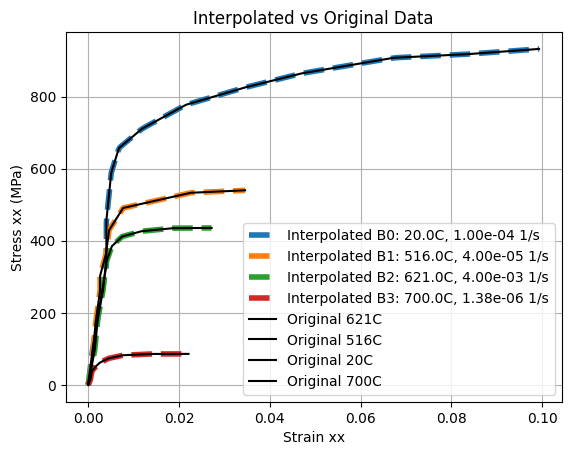

In [32]:
# Initial data shape
for temp_label in strain_data:
    print(f"Initial data size for {temp_label}: {stress_data[temp_label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, T in enumerate(temperatures):
    # t_label in Celsius for dict lookup
    t_label = str(int(T.item() - 273))
    
    f_strain = torch.nn.functional.interpolate(strain_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    f_stress = torch.nn.functional.interpolate(stress_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    
    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
    
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

print("Saturated Stress values")
print(f"{[exp_stress_data[-1, i, 0].item() for i, _ in enumerate(temperatures)]:}")

# Plot interpolated data
plt.figure()
for i, T in enumerate(temperatures):
    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--', color=f'C{i}', lw=4, label=f"Interpolated {label}")
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), color='k', label=f"Original {temp_label}C")
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()


Temp 20C: E = 100000.00 MPa, E_exp = 101807.47 MPa
  Yield stress: 676.74 MPa at strain: 0.0086
Temp 516C: E = 75000.00 MPa, E_exp = 76634.31 MPa
  Yield stress: 492.91 MPa at strain: 0.0084
Temp 621C: E = 67000.00 MPa, E_exp = 67211.36 MPa
  Yield stress: 413.98 MPa at strain: 0.0082
Temp 700C: E = 30000.00 MPa, E_exp = 29890.25 MPa
  Yield stress: 73.25 MPa at strain: 0.0045


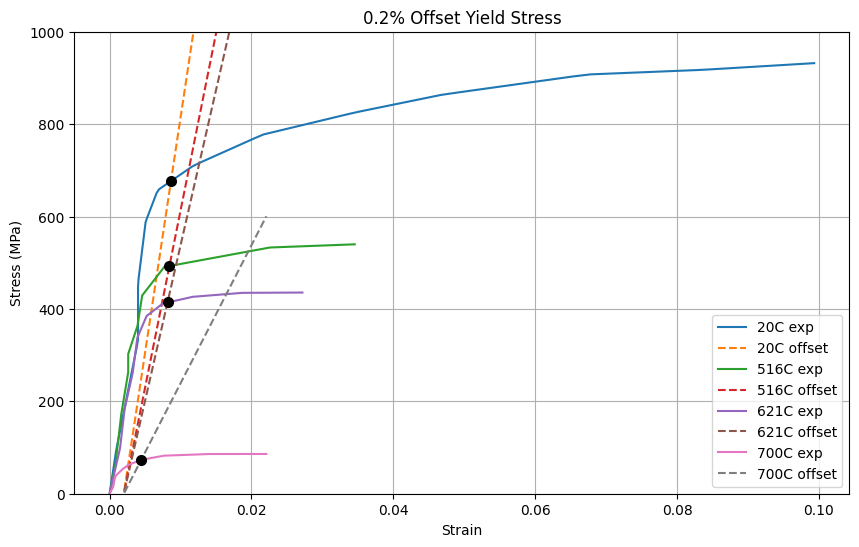


Experimental E values: [101807.46502653  76634.31232093  67211.3619677   29890.25012762]
Experimental sy values: [676.73816576 492.90807825 413.98290585  73.25199063]
Experimental G values: [39156.7173179  29474.73550805 25850.52383373 11496.25004908]
Updated E_Y:  tensor([101807.4650,  76634.3123,  67211.3620,  29890.2501], device='cuda:0')
Updated sy_Y: tensor([676.7382, 492.9081, 413.9829,  73.2520], device='cuda:0')
Updated G_Y:  tensor([39156.7173, 29474.7355, 25850.5238, 11496.2500], device='cuda:0')


In [33]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch()  # interpolation ordinate for E
sy = nmodel.sy_Y.tensor().clone().torch()  # interpolation ordinate for sy
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, T in enumerate(temperatures):
    temp_label = str(int(T.item() - 273))  # Celsius label for display/lookup

    # Calculate actual experimental Young's Modulus
    strain_initial = exp_strain_data[:5, i, 0].cpu().numpy()
    stress_initial = exp_stress_data[:5, i, 0].cpu().numpy()
    E_exp = np.polyfit(strain_initial, stress_initial, 1)[0]
    E_exps.append(E_exp)
    print(f"Temp {temp_label}C: E = {E[i]:.2f} MPa, E_exp = {E_exp:.2f} MPa")

    # Grab experimental data (keep on GPU)
    stress_exp = exp_stress_data[:, i, 0]
    strain_range = exp_strain_data[:, i, 0]

    # Build 0.2% offset line: E * (strain - 0.002), zero below offset
    valid_idx = strain_range >= offset
    stress_offset = torch.zeros_like(strain_range)
    stress_offset[valid_idx] = E_exp * (strain_range[valid_idx] - offset)

    # Find yield point: first sign change of (stress_exp - stress_offset) in valid region
    diff = stress_exp - stress_offset
    diff_valid = diff[valid_idx]
    strain_valid = strain_range[valid_idx]
    stress_valid = stress_exp[valid_idx]

    sign_changes = torch.where(torch.diff(torch.sign(diff_valid)) != 0)[0]

    if len(sign_changes) > 0:
        idx = sign_changes[0].item()
        # Linear interpolation between the two bracketing points
        d0, d1 = diff_valid[idx].item(), diff_valid[idx + 1].item()
        s0, s1 = strain_valid[idx].item(), strain_valid[idx + 1].item()
        se0, se1 = stress_valid[idx].item(), stress_valid[idx + 1].item()

        t = d0 / (d0 - d1)  # interpolation parameter in [0, 1]
        yield_strain = s0 + t * (s1 - s0)
        yield_stress = se0 + t * (se1 - se0)

        sy_exps.append(yield_stress)
        print(f"  Yield stress: {yield_stress:.2f} MPa at strain: {yield_strain:.4f}")
        plt.plot(yield_strain, yield_stress, "ko", markersize=7, zorder=5)
    else:
        print(f"  WARNING: No intersection found for {temp_label}C; using current model sy for this temperature")
        sy_exps.append(float(sy[i].item()))

    # Plot experimental curve and offset line
    plt.plot(strain_range.cpu().numpy(), stress_exp.cpu().numpy(), "-", label=f"{temp_label}C exp")
    plt.plot(
        strain_range[valid_idx].cpu().numpy(),
        stress_offset[valid_idx].cpu().numpy(),
        "--",
        label=f"{temp_label}C offset",
    )

plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("0.2% Offset Yield Stress")
plt.legend()
plt.grid()
plt.ylim((0.0, 1000.0))
plt.show()

# Replace model parameters with experimental values to improve training
E_exps = np.array(E_exps)
sy_exps = np.array(sy_exps)

# Compute G from experimental E: G = E / (2*(1+nu))
G_exps = E_exps / (2.0 * (1.0 + nu.cpu().numpy()))

print(f"\nExperimental E values: {E_exps}")
print(f"Experimental sy values: {sy_exps}")
print(f"Experimental G values: {G_exps}")

# For interpolation models these are ordinate vectors; enforce strict length = ntemperature
if len(E_exps) != ntemperature or len(sy_exps) != ntemperature or len(G_exps) != ntemperature:
    raise RuntimeError(
        f"Parameter vector length mismatch: E={len(E_exps)}, sy={len(sy_exps)}, G={len(G_exps)}, expected {ntemperature}"
    )

E_tensor = torch.tensor(E_exps, device=device, dtype=torch.double)
sy_tensor = torch.tensor(sy_exps, device=device, dtype=torch.double)
G_tensor = torch.tensor(G_exps, device=device, dtype=torch.double)

with torch.no_grad():
    E_param = nmodel.E_Y.tensor().torch()
    sy_param = nmodel.sy_Y.tensor().torch()
    G_param = nmodel.G_Y.tensor().torch()

    if E_param.numel() != ntemperature or sy_param.numel() != ntemperature or G_param.numel() != ntemperature:
        raise RuntimeError(
            f"Model interpolation ordinate size mismatch: E_Y={E_param.numel()}, sy_Y={sy_param.numel()}, G_Y={G_param.numel()}, expected {ntemperature}"
        )

    E_param.copy_(E_tensor)
    sy_param.copy_(sy_tensor)
    G_param.copy_(G_tensor)
    print(f"Updated E_Y:  {nmodel.E_Y.tensor().torch()}")
    print(f"Updated sy_Y: {nmodel.sy_Y.tensor().torch()}")
    print(f"Updated G_Y:  {nmodel.G_Y.tensor().torch()}")

In [34]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.Bk_Y: tensor([0.0001, 0.0001, 0.0001, 0.0001], device='cuda:0'), torch.Size([4])

discrete_equations.C_Y: tensor([46600., 27000., 21750.,  4300.], device='cuda:0'), torch.Size([4])

discrete_equations.H_0_Y: tensor([0.5000, 0.5000, 0.5000, 0.5000], device='cuda:0'), torch.Size([4])

discrete_equations.T_0_Y: tensor([234.5200, 631.3200, 715.3200, 778.5200], device='cuda:0'), torch.Size([4])

discrete_equations.g_Y: tensor([40., 40., 40., 40.], device='cuda:0'), torch.Size([4])

discrete_equations.k1_Y: tensor([100000000., 100000000., 100000000., 100000000.], device='cuda:0'), torch.Size([4])

discrete_equations.k2_Y: tensor([10., 10., 10., 10.], device='cuda:0'), torch.Size([4])



In [35]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[0.0000e+00],
         [0.0000e+00],
         [0.0000e+00],
         [0.0000e+00]],

        [[3.1317e+01],
         [6.9040e+00],
         [4.4783e+00],
         [8.7039e-01]],

        [[6.1904e+01],
         [1.3743e+01],
         [8.9212e+00],
         [1.7336e+00]],

        [[9.1764e+01],
         [2.0518e+01],
         [1.3330e+01],
         [2.5897e+00]],

        [[1.2090e+02],
         [2.7229e+01],
         [1.7704e+01],
         [3.4386e+00]],

        [[1.4931e+02],
         [3.3876e+01],
         [2.2045e+01],
         [4.2806e+00]],

        [[1.7701e+02],
         [4.0459e+01],
         [2.6351e+01],
         [5.1155e+00]],

        [[2.0400e+02],
         [4.6979e+01],
         [3.0624e+01],
         [5.9434e+00]],

        [[2.3028e+02],
         [5.3435e+01],
         [3.4863e+01],
         [6.7644e+00]],

        [[2.5586e+02],
         [5.9828e+01],
         [3.9068e+01],
         [7.5785e+00]],

        [[2.8075e+02],
         [6.6158e+01],
         [4.32

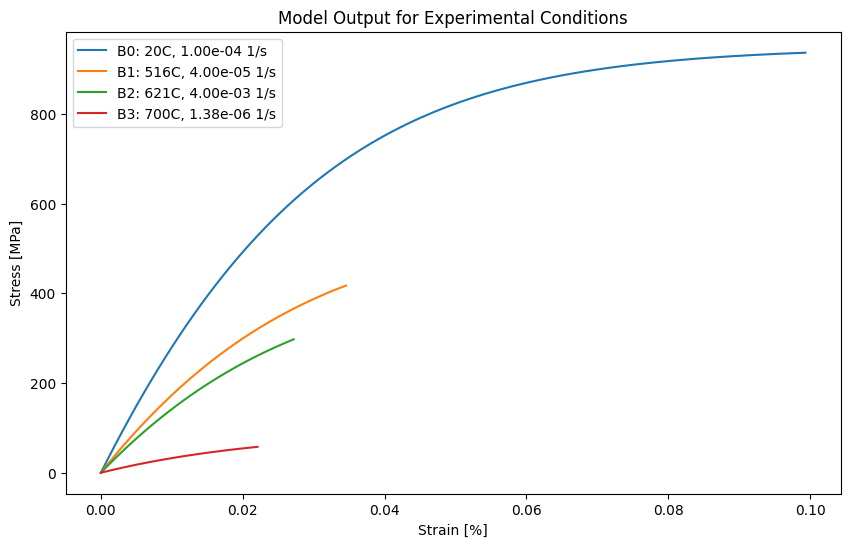

In [36]:
plt.figure(figsize=(10,6))
for i, T in enumerate(temperatures):
    temp_c = str(int(T.item() - 273))
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c}C, {rate_i:.2e} 1/s"
    plt.plot(loading[:, i, 0].cpu().numpy(), stress[:, i, 0].cpu().numpy(), label=label)
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')
plt.title('Model Output for Experimental Conditions')
plt.legend()

In [14]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch()  # interpolation ordinate for E
sy = nmodel.sy_Y.tensor().clone().torch()  # interpolation ordinate for sy
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, T in enumerate(temperatures):
    temp_label = str(int(T.item() - 273))  # Celsius label for display/lookup

    # Calculate actual experimental Young's Modulus
    strain_initial = loading[:5, i, 0].cpu().numpy()
    stress_initial = stress[:5, i, 0].cpu().numpy()
    E_exp = np.polyfit(strain_initial, stress_initial, 1)[0]
    E_exps.append(E_exp)
    print(f"Temp {temp_label}C: E = {E[i]:.2f} MPa, E_exp = {E_exp:.2f} MPa")

Temp 20C: E = 101807.47 MPa, E_exp = 30125.23 MPa
Temp 516C: E = 76634.31 MPa, E_exp = 19503.07 MPa
Temp 621C: E = 67211.36 MPa, E_exp = 16120.16 MPa
Temp 700C: E = 29890.25 MPa, E_exp = 3852.34 MPa


<Figure size 1000x600 with 0 Axes>

In [11]:
Bk_scaler = reparametrization.RangeRescale(torch.tensor([1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8], device=device), torch.tensor([5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3], device=device))
C_scaler = reparametrization.RangeRescale(torch.tensor([100.0, 100.0, 100.0, 100.0], device=device), torch.tensor([50000.0, 50000.0, 50000.0, 50000.0], device=device))
H_0_scaler = reparametrization.RangeRescale(torch.tensor([0.1, 0.1, 0.1, 0.1], device=device), torch.tensor([2.0, 2.0, 2.0, 2.0], device=device))
T_0_scaler = reparametrization.RangeRescale(torch.tensor([100.0, 100.0, 100.0, 100.0], device=device), torch.tensor([5000.0, 5000.0, 5000.0, 5000.0], device=device))
g_scaler = reparametrization.RangeRescale(torch.tensor([0.01, 0.01, 0.01, 0.01], device=device), torch.tensor([500.0, 500.0, 500.0, 500.0], device=device))
k1_scaler = reparametrization.RangeRescale(torch.tensor([0.01, 0.01, 0.01, 0.01], device=device), torch.tensor([10.0, 10.0, 10.0, 10.0], device=device))
k2_scaler = reparametrization.RangeRescale(torch.tensor([0.01, 0.01, 0.01, 0.01], device=device), torch.tensor([50.0, 50.0, 50.0, 50.0], device=device))
tau_p_scaler = reparametrization.RangeRescale(torch.tensor([50.0, 50.0, 50.0, 50.0], device=device), torch.tensor([3000.0, 3000.0, 3000.0, 3000.0], device=device))

model_reparameterizer = reparametrization.Reparameterizer(
    {"discrete_equations.Bk_Y": Bk_scaler,
     "discrete_equations.C_Y": C_scaler,
     "discrete_equations.H_0_Y": H_0_scaler,
     "discrete_equations.T_0_Y": T_0_scaler,
     "discrete_equations.g_Y": g_scaler,
     "discrete_equations.k1_Y": k1_scaler,
     "discrete_equations.k2_Y": k2_scaler,
     "discrete_equations.tau_p_Y": tau_p_scaler}, error_not_provided=True)
model_reparameterizer(model)
print(f'--- After Reparameterization ---')
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f'{n}: {p.data}, requires_grad={p.requires_grad}')

--- After Reparameterization ---
discrete_equations.parametrizations.Bk_Y.original: tensor([0.0200, 0.0200, 0.0200, 0.0200], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.C_Y.original: tensor([0.9319, 0.5391, 0.4339, 0.0842], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.H_0_Y.original: tensor([0.2105, 0.2105, 0.2105, 0.2105], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.T_0_Y.original: tensor([0.0275, 0.1084, 0.1256, 0.1385], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.g_Y.original: tensor([0.0800, 0.0800, 0.0800, 0.0800], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k1_Y.original: tensor([0.0040, 0.0040, 0.0040, 0.0040], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k2_Y.original: tensor([0.1998, 0.1998, 0.1998, 0.1998], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.tau_p_Y.original: tensor([0.

Available state variables:
  state/internal/Kp
  state/internal/X
  state/internal/rho_m
  state/mixed_state

Batch 0: T=20.0C, rate=1.000e-04 1/s
rho_m: start=1.000000e+12, end=2.335940e+13
||X||: start=0.000000e+00, end=7.646989e+02
||Kp||: start=0.000000e+00, end=1.103769e-01

Batch 1: T=516.0C, rate=4.000e-05 1/s
rho_m: start=1.000000e+12, end=6.121930e+12
||X||: start=0.000000e+00, end=3.407716e+02
||Kp||: start=0.000000e+00, end=3.565068e-02

Batch 2: T=621.0C, rate=4.000e-03 1/s
rho_m: start=1.000000e+12, end=4.727063e+12
||X||: start=0.000000e+00, end=2.428663e+02
||Kp||: start=0.000000e+00, end=2.787091e-02

Batch 3: T=700.0C, rate=1.380e-06 1/s
rho_m: start=1.000000e+12, end=4.205685e+12
||X||: start=0.000000e+00, end=4.713197e+01
||Kp||: start=0.000000e+00, end=2.472822e-02


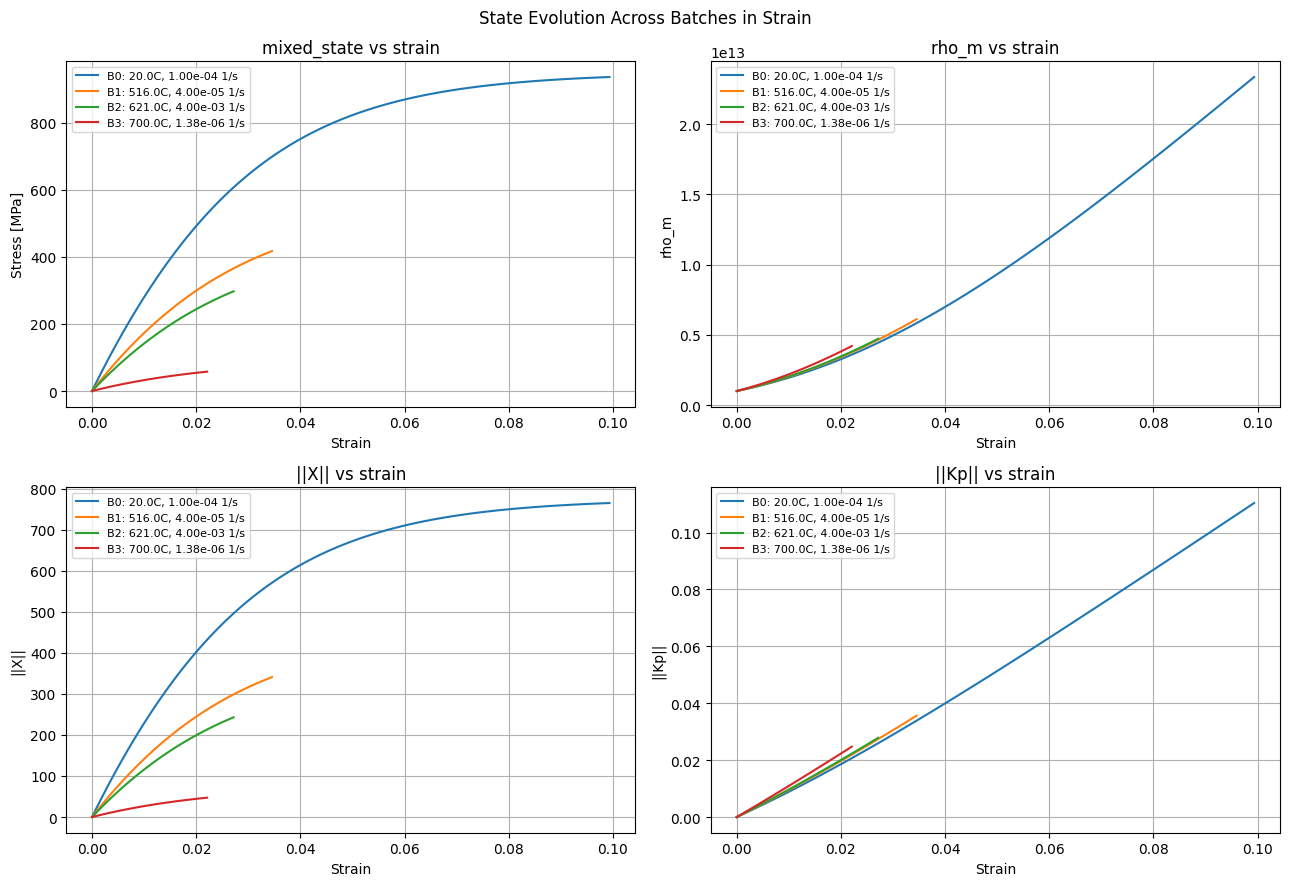

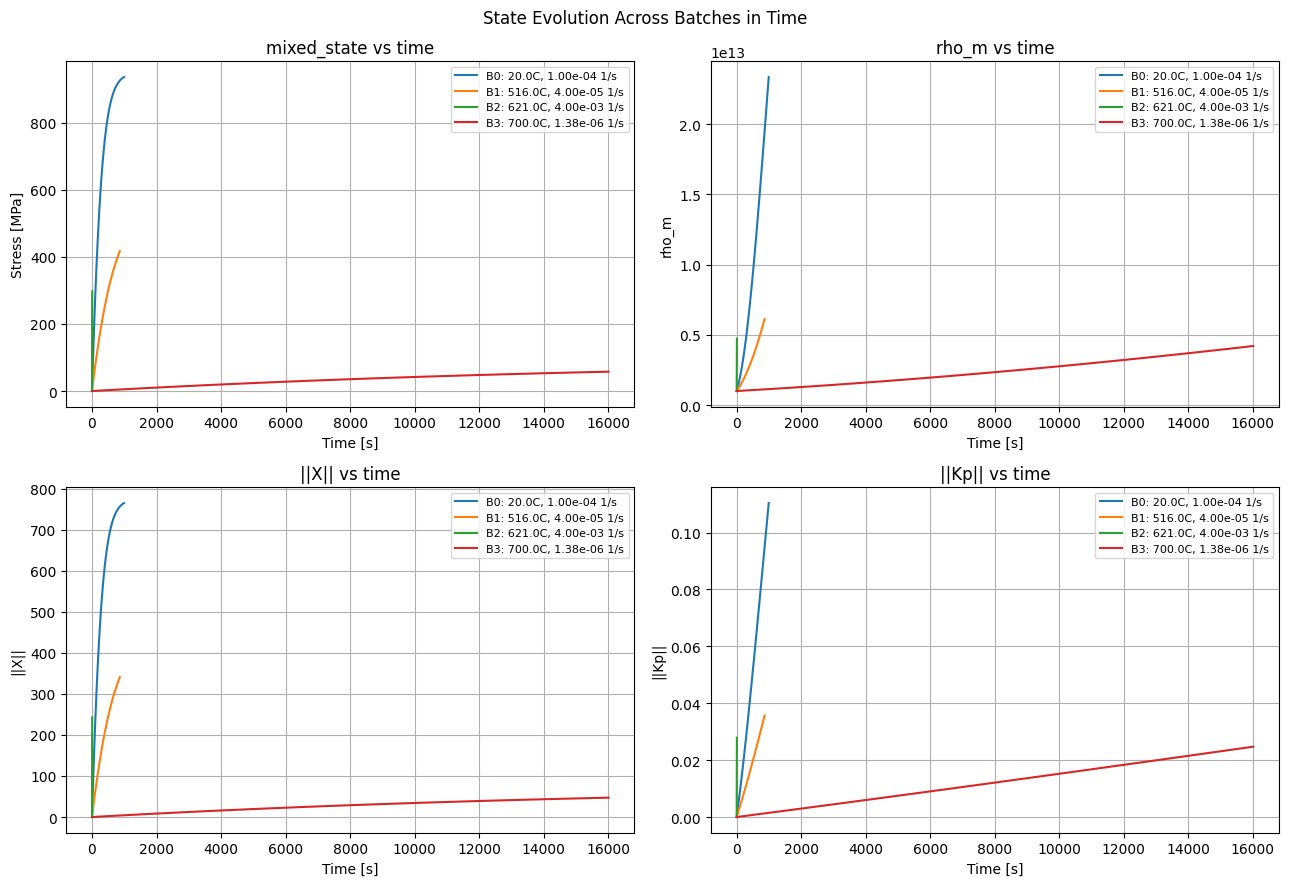

In [37]:
# Debug: inspect internal-variable evolution over time; overlay all batches on two 2x2 figures
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

available_names = sorted(state_hist.keys())
print("Available state variables:")
for name in available_names:
    print(" ", name)

def get_hist(name):
    return state_hist[name].torch() if name in state_hist else None

rho_m = get_hist("state/internal/rho_m")
X = get_hist("state/internal/X")
Kp = get_hist("state/internal/Kp")

fig_s, ax_s = plt.subplots(2, 2, figsize=(13, 9))
fig_s.suptitle("State Evolution Across Batches in Strain")

fig_t, ax_t = plt.subplots(2, 2, figsize=(13, 9))
fig_t.suptitle("State Evolution Across Batches in Time")

for i, T in enumerate(temperatures):
    strain_hist = loading[:, i, 0].detach().cpu()
    time_hist = time[:, i, 0].detach().cpu()
    stress11 = stress[:, i, 0].detach().cpu() if stress is not None else None
    rho_m_hist = rho_m[:, i, 0].detach().cpu() if rho_m is not None else None
    x_norm_hist = torch.linalg.norm(X[:, i, :], dim=-1).detach().cpu() if X is not None else None
    kp_norm_hist = torch.linalg.norm(Kp[:, i, :], dim=-1).detach().cpu() if Kp is not None else None

    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"

    print(f"\nBatch {i}: T={temp_c:.1f}C, rate={rate_i:.3e} 1/s")
    if rho_m_hist is not None:
        print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
    if x_norm_hist is not None:
        print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")
    if kp_norm_hist is not None:
        print(f"||Kp||: start={kp_norm_hist[0].item():.6e}, end={kp_norm_hist[-1].item():.6e}")

    if stress11 is not None:
        ax_s[0, 0].plot(strain_hist.numpy(), stress11.numpy(), label=label)
        ax_t[0, 0].plot(time_hist.numpy(), stress11.numpy(), label=label)
    if rho_m_hist is not None:
        ax_s[0, 1].plot(strain_hist.numpy(), rho_m_hist.numpy(), label=label)
        ax_t[0, 1].plot(time_hist.numpy(), rho_m_hist.numpy(), label=label)
    if x_norm_hist is not None:
        ax_s[1, 0].plot(strain_hist.numpy(), x_norm_hist.numpy(), label=label)
        ax_t[1, 0].plot(time_hist.numpy(), x_norm_hist.numpy(), label=label)
    if kp_norm_hist is not None:
        ax_s[1, 1].plot(strain_hist.numpy(), kp_norm_hist.numpy(), label=label)
        ax_t[1, 1].plot(time_hist.numpy(), kp_norm_hist.numpy(), label=label)

ax_s[0, 0].set_title("mixed_state vs strain")
ax_s[0, 0].set_xlabel("Strain")
ax_s[0, 0].set_ylabel("Stress [MPa]")
ax_s[0, 0].grid(True)
ax_s[0, 0].legend(fontsize=8)

ax_s[0, 1].set_title("rho_m vs strain")
ax_s[0, 1].set_xlabel("Strain")
ax_s[0, 1].set_ylabel("rho_m")
ax_s[0, 1].grid(True)
ax_s[0, 1].legend(fontsize=8)

ax_s[1, 0].set_title("||X|| vs strain")
ax_s[1, 0].set_xlabel("Strain")
ax_s[1, 0].set_ylabel("||X||")
ax_s[1, 0].grid(True)
ax_s[1, 0].legend(fontsize=8)

ax_s[1, 1].set_title("||Kp|| vs strain")
ax_s[1, 1].set_xlabel("Strain")
ax_s[1, 1].set_ylabel("||Kp||")
ax_s[1, 1].grid(True)
ax_s[1, 1].legend(fontsize=8)

ax_t[0, 0].set_title("mixed_state vs time")
ax_t[0, 0].set_xlabel("Time [s]")
ax_t[0, 0].set_ylabel("Stress [MPa]")
ax_t[0, 0].grid(True)
ax_t[0, 0].legend(fontsize=8)

ax_t[0, 1].set_title("rho_m vs time")
ax_t[0, 1].set_xlabel("Time [s]")
ax_t[0, 1].set_ylabel("rho_m")
ax_t[0, 1].grid(True)
ax_t[0, 1].legend(fontsize=8)

ax_t[1, 0].set_title("||X|| vs time")
ax_t[1, 0].set_xlabel("Time [s]")
ax_t[1, 0].set_ylabel("||X||")
ax_t[1, 0].grid(True)
ax_t[1, 0].legend(fontsize=8)

ax_t[1, 1].set_title("||Kp|| vs time")
ax_t[1, 1].set_xlabel("Time [s]")
ax_t[1, 1].set_ylabel("||Kp||")
ax_t[1, 1].grid(True)
ax_t[1, 1].legend(fontsize=8)

fig_s.tight_layout()
fig_t.tight_layout()
plt.show()

In [38]:
lr = 1.0e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()
optimizer.zero_grad()
res = model(time, temperature, loading)
peak_stress = exp_stress_data[-1:, :, 0:1].detach()
loss = loss_fn(res / (peak_stress + 1e-8), exp_stress_data[..., 0:1] / (peak_stress + 1e-8))
loss.backward()

for n, param in model.named_parameters():
    if param.grad is not None:
        print(f"{n}: grad_norm = {param.grad.norm().item():.4e}, "
              f"value = {param.data}")
optimizer.zero_grad()

discrete_equations.Bk_Y: grad_norm = 4.6350e-01, value = tensor([0.0001, 0.0001, 0.0001, 0.0001], device='cuda:0')
discrete_equations.C_Y: grad_norm = 1.2142e-05, value = tensor([46600., 27000., 21750.,  4300.], device='cuda:0')
discrete_equations.H_0_Y: grad_norm = 2.8728e-04, value = tensor([0.5000, 0.5000, 0.5000, 0.5000], device='cuda:0')
discrete_equations.T_0_Y: grad_norm = 2.8298e-06, value = tensor([234.5200, 631.3200, 715.3200, 778.5200], device='cuda:0')
discrete_equations.g_Y: grad_norm = 9.1981e-04, value = tensor([40., 40., 40., 40.], device='cuda:0')
discrete_equations.k1_Y: grad_norm = 2.4555e-13, value = tensor([100000000., 100000000., 100000000., 100000000.], device='cuda:0')
discrete_equations.k2_Y: grad_norm = 4.5866e-07, value = tensor([10., 10., 10., 10.], device='cuda:0')
